# <center>Data ingestion
</center>

In [24]:
import pandas as pd

columns = [
    "index",
    "Lever position (Lp)",
    "Ship speed (V) [knots]",
    "Gas Turbine shaft torque (GTT) [kN/m]",
    "Gas Turbine revolutions (GTn) [rpm]",
    "Gas Generator revolutions (GGn) [rpm]",
    "Starboard Propeller Torque (Ts) [kN/m]",
    "Port Propeller Torque (Tp) [kN/m]",
    "HP Turbine exit temperature (T48) [°C]",
    "Compressor inlet air temperature (T1) [°C]",
    "Compressor outlet air temperature (T2) [°C]",
    "HP Turbine exit pressure (P48) [bar]",
    "Compressor inlet air pressure (P1) [bar]",
    "Compressor outlet air pressure (P2) [bar]",
    "Exhaust gas pressure [bar]",
    "Turbine Injection Control (TIC) [%]",
    "Fuel flow (mf) [kg/s]",
    "Compressor decay coefficient",
    "Turbine decay coefficient"
]

df = pd.read_csv("./data/data.txt", 
                 sep=r'\s+', 
                 header=None)

df.index = df.index + 1
df.reset_index(inplace=True)
df.columns = columns

# Save to CSV
df.to_csv("./data/turbine_data.csv", index=False)


print("Converted Sensor logs txt (data.txt) --> csv (turbine_data.csv)\n")
print("First 5 rows of Unprocessed data")
print(df.head())



Converted Sensor logs txt (data.txt) --> csv (turbine_data.csv)

First 5 rows of Unprocessed data
   index  Lever position (Lp)  Ship speed (V) [knots]  \
0      1                1.138                     3.0   
1      2                2.088                     6.0   
2      3                3.144                     9.0   
3      4                4.161                    12.0   
4      5                5.140                    15.0   

   Gas Turbine shaft torque (GTT) [kN/m]  Gas Turbine revolutions (GTn) [rpm]  \
0                                289.964                             1349.489   
1                               6960.180                             1376.166   
2                               8379.229                             1386.757   
3                              14724.395                             1547.465   
4                              21636.432                             1924.313   

   Gas Generator revolutions (GGn) [rpm]  \
0                           

# <center> Data Cleaning & Transformation</center>

#### Handle nulls, outliers, smoothing

In [26]:
# Keep first column as integer
df['index'] = df['index'].astype(int)

# Select all other numeric columns exclude index
numeric_cols = df.columns[1:] 

# Fill numeric nulls with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Outlier using (IQR Method)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

# Smoothing values
df[numeric_cols] = df[numeric_cols].rolling(window=3, min_periods=1).mean()

# Round numbers to 2 decimals
df[numeric_cols] = df[numeric_cols].round(2)

print("Cleaned Data")
print(df.head())

Cleaned Data
   index  Lever position (Lp)  Ship speed (V) [knots]  \
0      1                 1.14                    3.00   
1      2                 1.38                    3.75   
2      3                 1.62                    4.50   
3      4                 2.29                    6.50   
4      5                 3.13                    9.00   

   Gas Turbine shaft torque (GTT) [kN/m]  Gas Turbine revolutions (GTn) [rpm]  \
0                                 289.96                              1349.49   
1                                1957.52                              1356.16   
2                                3041.61                              1361.04   
3                                6285.38                              1390.14   
4                               10048.14                              1475.70   

   Gas Generator revolutions (GGn) [rpm]  \
0                                6677.38   
1                                6715.15   
2                        

#### Derived Features : Temp_ratio_T48_T2, Temp_ratio_T1_P1, Torque_diff, RPM_ratio_GTn_GGn, Fuel_per_RPM, Total_Prop_Torque

In [27]:
import numpy as np
# Temperature-Pressure Ratios
df['Temp_ratio_T48_P48'] = (df['HP Turbine exit temperature (T48) [°C]'] / 
                           df['HP Turbine exit pressure (P48) [bar]']).round(2)
df['Temp_ratio_T1_P1'] = (df['Compressor inlet air temperature (T1) [°C]'] / 
                          df['Compressor inlet air pressure (P1) [bar]']).round(2)
df['Temp_ratio_T2_P2'] =  (df['Compressor outlet air temperature (T2) [°C]'] / 
                          df['Compressor outlet air pressure (P2) [bar]']).round(2)
# Torque Differentials
df['Torque_diff'] = (df['Starboard Propeller Torque (Ts) [kN/m]'] - 
                     df['Port Propeller Torque (Tp) [kN/m]']).round(2)

# Efficiency Indicators
df['RPM_ratio_GTn_GGn'] = (df['Gas Turbine revolutions (GTn) [rpm]'] / 
                           df['Gas Generator revolutions (GGn) [rpm]']).round(2)
df['Fuel_per_RPM'] = (df['Fuel flow (mf) [kg/s]'] / df['Gas Turbine revolutions (GTn) [rpm]']).round(5)

# Total Propeller Torque
df['Total_Prop_Torque'] = (df['Starboard Propeller Torque (Ts) [kN/m]'] +
                            df['Port Propeller Torque (Tp) [kN/m]']).round(2)

angular_velocity_rad_s = df['Gas Turbine revolutions (GTn) [rpm]'] * (2 * np.pi / 60)
df['Power_Proxy_kW'] = (
    df['Gas Turbine shaft torque (GTT) [kN/m]'] * angular_velocity_rad_s
).round(2)

# --- Total Decay Score ---
df['Total_decay_score'] = (
    (1 - df['Compressor decay coefficient']) + (1 - df['Turbine decay coefficient'])
).round(3)

pd.set_option('display.max_columns', None)
print("Cleaned Data with Derived Features")
print(df.head())


Cleaned Data with Derived Features
   index  Lever position (Lp)  Ship speed (V) [knots]  \
0      1                 1.14                    3.00   
1      2                 1.38                    3.75   
2      3                 1.62                    4.50   
3      4                 2.29                    6.50   
4      5                 3.13                    9.00   

   Gas Turbine shaft torque (GTT) [kN/m]  Gas Turbine revolutions (GTn) [rpm]  \
0                                 289.96                              1349.49   
1                                1957.52                              1356.16   
2                                3041.61                              1361.04   
3                                6285.38                              1390.14   
4                               10048.14                              1475.70   

   Gas Generator revolutions (GGn) [rpm]  \
0                                6677.38   
1                                6715.15   
2  

#### EDA (Exploratory Data Analysis)

- Summary statistics
- Null check
- Correlation heatmap
- Histograms
- Boxplots
- Pair plots


In [28]:
print("Summary Statistics ")
print(df.describe())

Summary Statistics 
              index  Lever position (Lp)  Ship speed (V) [knots]  \
count  11934.000000         11934.000000            11934.000000   
mean    5967.500000             5.163248               14.996460   
std     3445.193391             1.511353                4.475722   
min        1.000000             1.140000                3.000000   
25%     2984.250000             4.150000               12.000000   
50%     5967.500000             5.150000               15.000000   
75%     8950.750000             6.200000               18.000000   
max    11934.000000             7.200000               21.000000   

       Gas Turbine shaft torque (GTT) [kN/m]  \
count                           11934.000000   
mean                            27238.051382   
std                             12444.122407   
min                               289.960000   
25%                             15260.492500   
50%                             24838.015000   
75%                            

In [29]:
print("\nTotal Null Values ")
print(df.isnull().sum())



Total Null Values 
index                                          0
Lever position (Lp)                            0
Ship speed (V) [knots]                         0
Gas Turbine shaft torque (GTT) [kN/m]          0
Gas Turbine revolutions (GTn) [rpm]            0
Gas Generator revolutions (GGn) [rpm]          0
Starboard Propeller Torque (Ts) [kN/m]         0
Port Propeller Torque (Tp) [kN/m]              0
HP Turbine exit temperature (T48) [°C]         0
Compressor inlet air temperature (T1) [°C]     0
Compressor outlet air temperature (T2) [°C]    0
HP Turbine exit pressure (P48) [bar]           0
Compressor inlet air pressure (P1) [bar]       0
Compressor outlet air pressure (P2) [bar]      0
Exhaust gas pressure [bar]                     0
Turbine Injection Control (TIC) [%]            0
Fuel flow (mf) [kg/s]                          0
Compressor decay coefficient                   0
Turbine decay coefficient                      0
Temp_ratio_T48_P48                             0


In [30]:
numeric_cols = df.columns[1:]
corr_matrix = df[numeric_cols].corr()
print("\nCorrelation Matrix ")
print(corr_matrix)


Correlation Matrix 
                                             Lever position (Lp)  \
Lever position (Lp)                                     1.000000   
Ship speed (V) [knots]                                  0.999960   
Gas Turbine shaft torque (GTT) [kN/m]                   0.949271   
Gas Turbine revolutions (GTn) [rpm]                     0.955061   
Gas Generator revolutions (GGn) [rpm]                   0.993999   
Starboard Propeller Torque (Ts) [kN/m]                  0.946319   
Port Propeller Torque (Tp) [kN/m]                       0.946319   
HP Turbine exit temperature (T48) [°C]                  0.956170   
Compressor inlet air temperature (T1) [°C]                   NaN   
Compressor outlet air temperature (T2) [°C]             0.978420   
HP Turbine exit pressure (P48) [bar]                    0.950587   
Compressor inlet air pressure (P1) [bar]                     NaN   
Compressor outlet air pressure (P2) [bar]               0.959186   
Exhaust gas pressure [bar] 

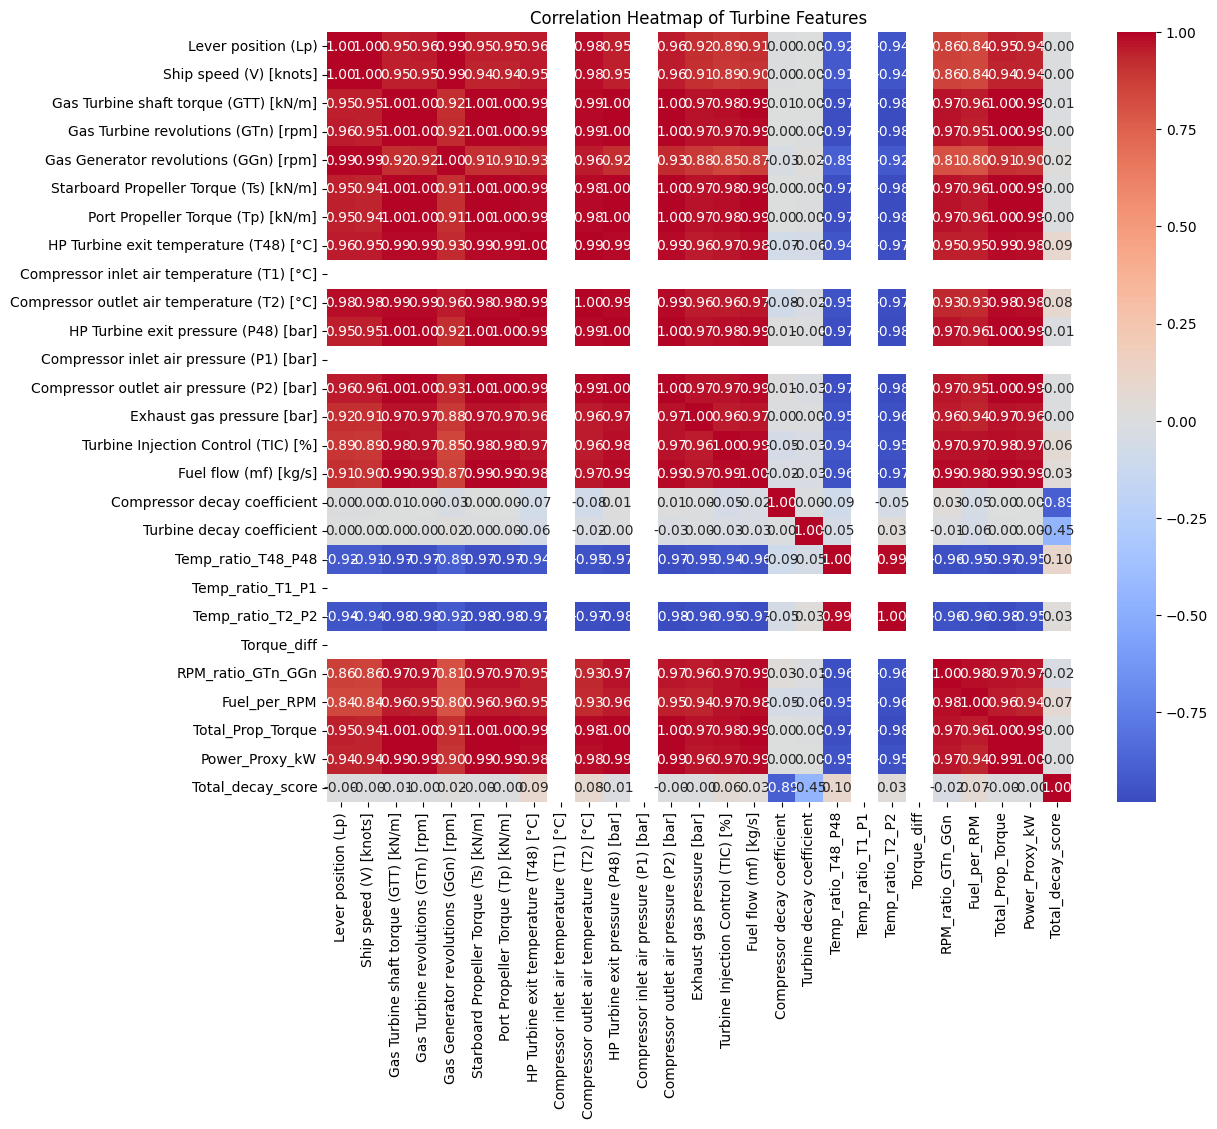

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Turbine Features")
plt.show()

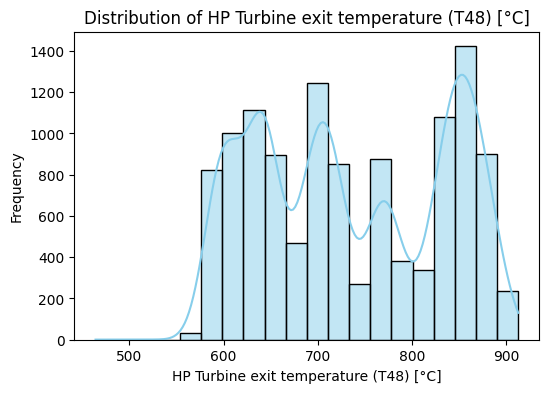

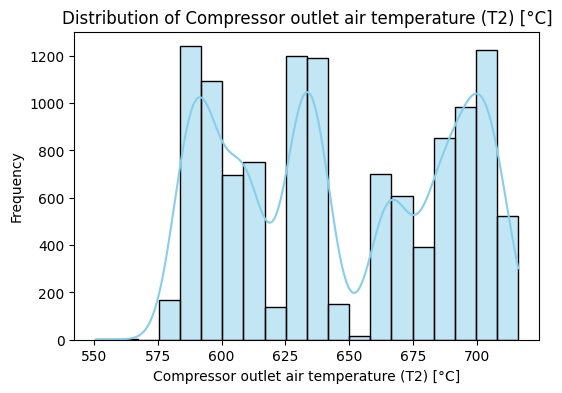

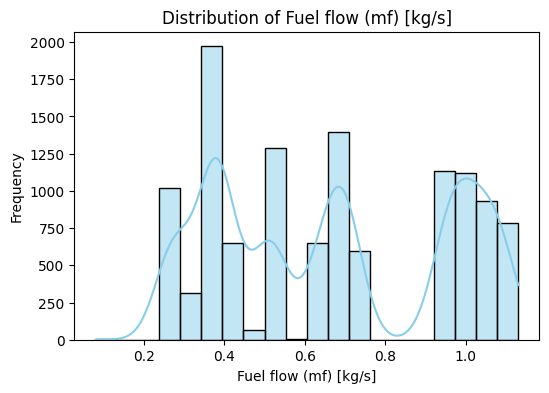

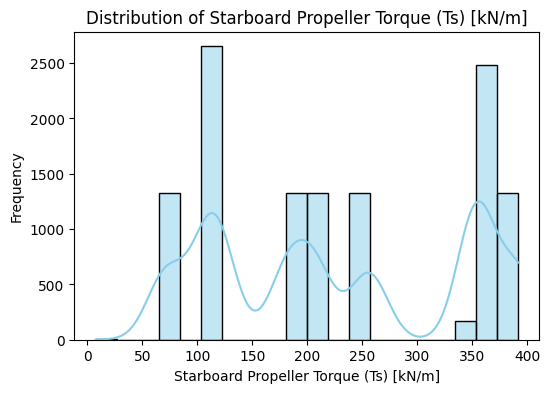

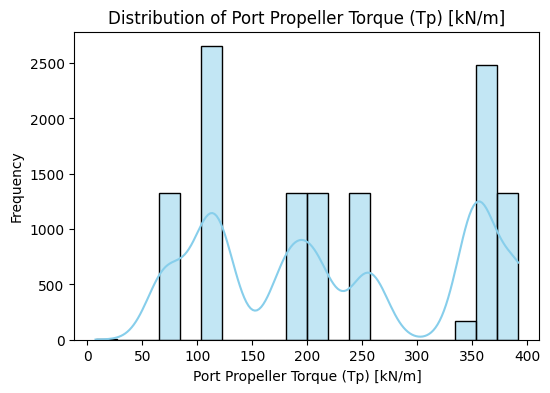

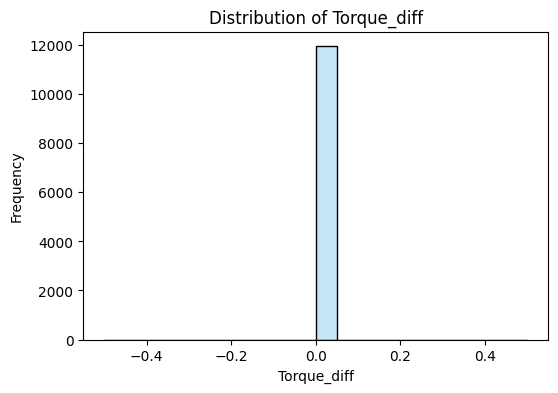

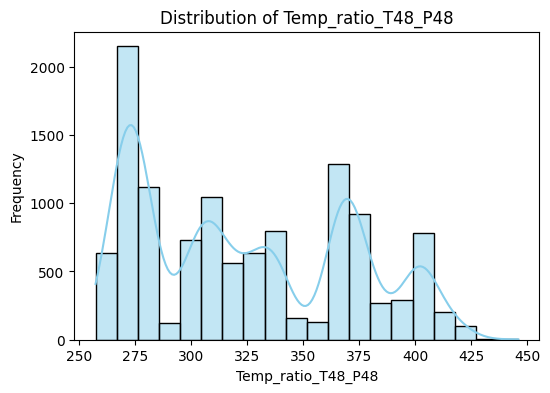

In [32]:
#Distributions of Key Columns
key_cols = ['HP Turbine exit temperature (T48) [°C]',
            'Compressor outlet air temperature (T2) [°C]',
            'Fuel flow (mf) [kg/s]',
            'Starboard Propeller Torque (Ts) [kN/m]',
            'Port Propeller Torque (Tp) [kN/m]',
            'Torque_diff',
            'Temp_ratio_T48_P48']

for col in key_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


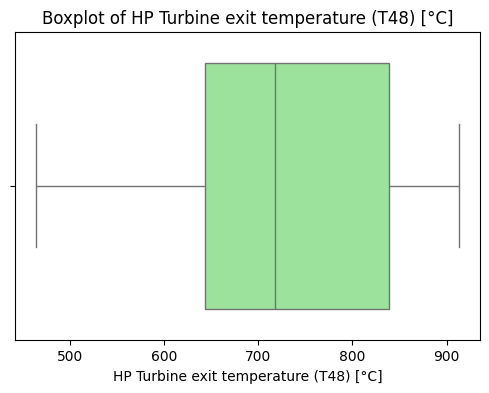

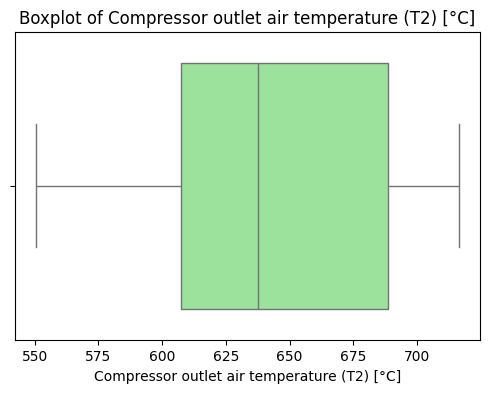

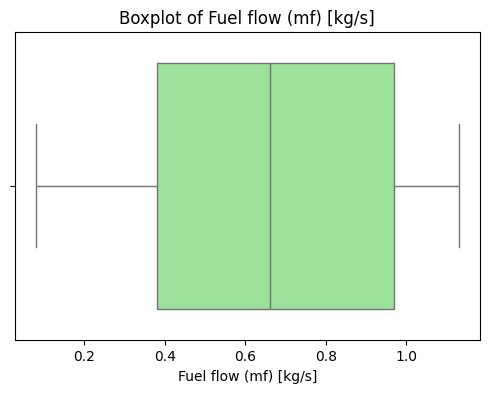

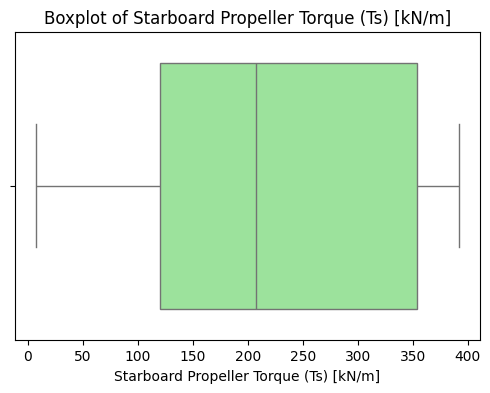

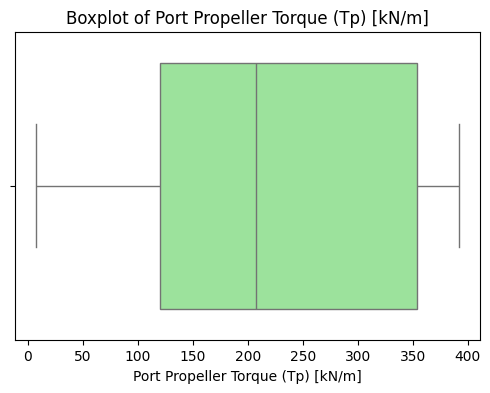

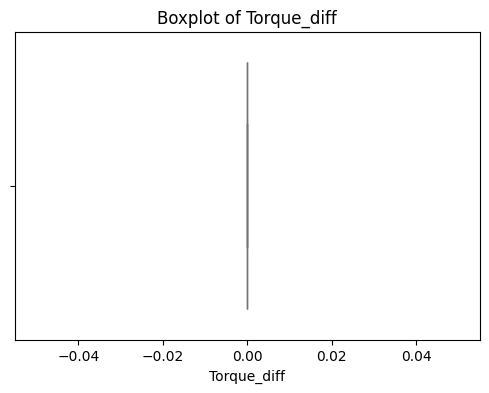

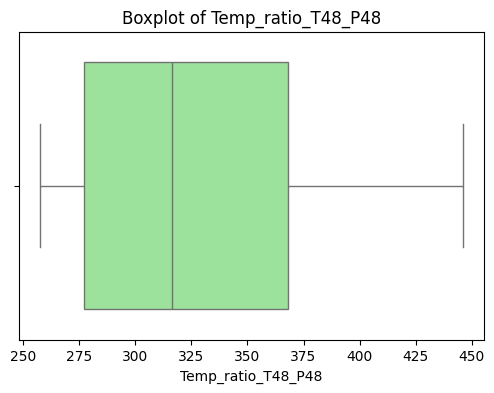

In [33]:
#Boxplots to detect remaining outliers
for col in key_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"Boxplot of {col}")
    plt.show()

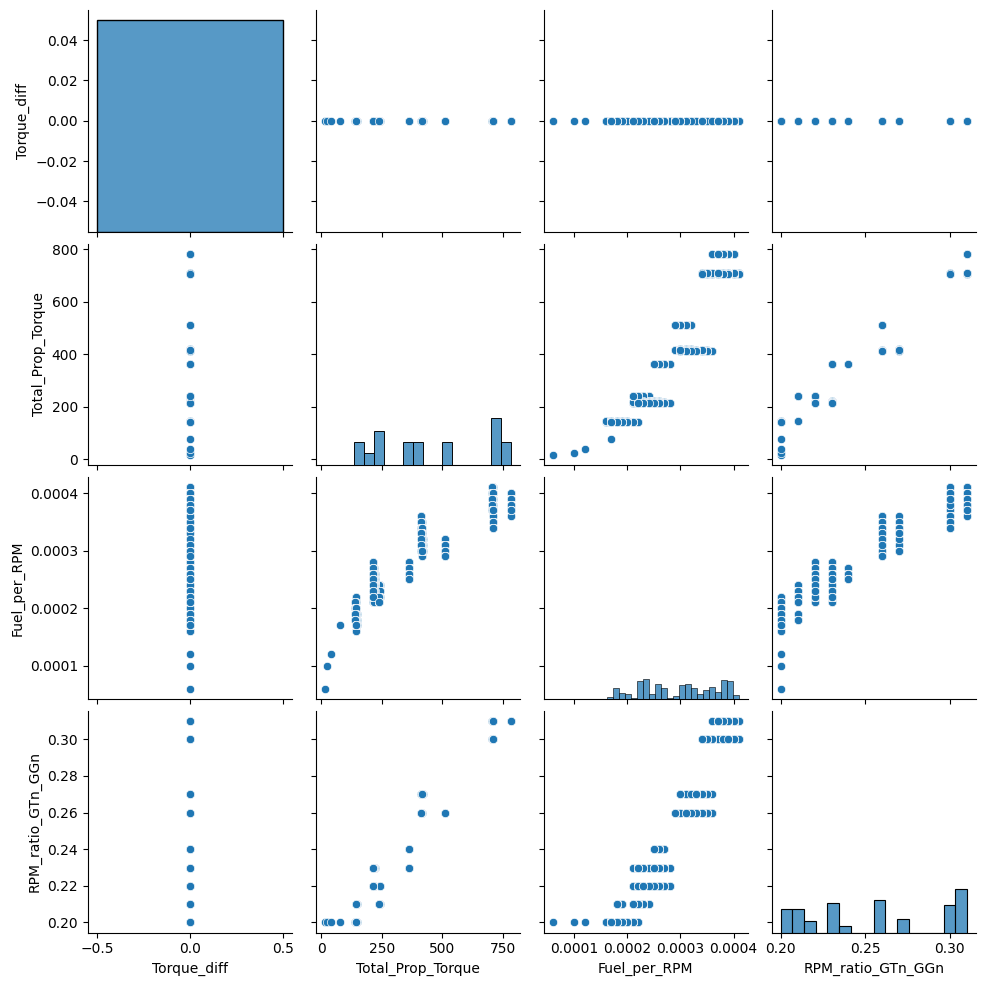

In [34]:
#Pairwise relationship
sns.pairplot(df[['Torque_diff', 'Total_Prop_Torque', 'Fuel_per_RPM', 'RPM_ratio_GTn_GGn']])
plt.show()

In [35]:
# Save df as cleaned csv
numeric_cols = df.columns[1:]  # exclude index
df[numeric_cols] = df[numeric_cols].round(2)

# Save to CSV again
df.to_csv("./data/turbine_data_cleaned.csv", index=False)
print("turbine_data_cleaned.csv created successfully")

turbine_data_cleaned.csv created successfully


In [37]:
import pandas as pd

df = pd.read_csv("./data/turbine_data_cleaned.csv")

# Rename columns to match SQL schema
df.rename(columns={
    "index": "id",  # optional if you don't want to keep CSV index
    "Lever position (Lp)": "lp",
    "Ship speed (V) [knots]": "v",
    "Gas Turbine shaft torque (GTT) [kN/m]": "gtt",
    "Gas Turbine revolutions (GTn) [rpm]": "gtn",
    "Gas Generator revolutions (GGn) [rpm]": "ggn",
    "Starboard Propeller Torque (Ts) [kN/m]": "ts",
    "Port Propeller Torque (Tp) [kN/m]": "tp",
    "HP Turbine exit temperature (T48) [°C]": "t48",
    "Compressor inlet air temperature (T1) [°C]": "t1",
    "Compressor outlet air temperature (T2) [°C]": "t2",
    "HP Turbine exit pressure (P48) [bar]": "p48",
    "Compressor inlet air pressure (P1) [bar]": "p1",
    "Compressor outlet air pressure (P2) [bar]": "p2",
    "Exhaust gas pressure [bar]": "pexh",
    "Turbine Injection Control (TIC) [%]": "tic",
    "Fuel flow (mf) [kg/s]": "mf",
    "Compressor decay coefficient": "decay_coeff_comp",
    "Turbine decay coefficient": "decay_coeff_turbine",
    "Temp_ratio_T48_P48": "temp_ratio_t48_p48",
    "Temp_ratio_T1_P1": "temp_ratio_t1_p1",
    "Temp_ratio_T2_P2": "temp_ratio_t2_p2",
    "Torque_diff": "torque_diff",
    "RPM_ratio_GTn_GGn": "rpm_ratio_gtn_ggn",
    "Fuel_per_RPM": "fuel_per_rpm",
    "Total_Prop_Torque": "total_prop_torque",
    "Power_Proxy_kW": "power_proxy_kw",
    "Total_decay_score": "total_decay_score"
}, inplace=True)

# Save the renamed DataFrame to a new CSV (or overwrite existing one)
df.to_csv("./data/turbine_data_renamed.csv", index=False)
print("turbine_data_renamed.csv created successfully")

turbine_data_renamed.csv created successfully


# <center>SQL & Exploratory Analysis</center>

#### SQL Table Creation

In [38]:
#SQlite database connection

import sqlite3
import pandas as pd
from sqlalchemy import create_engine

# Option 1: Using sqlite3 directly
conn = sqlite3.connect("./data/turbine_data.db")  # Creates DB file locally
cursor = conn.cursor()


#### turbine_metadata, sensor_reading Table schema

In [39]:
import sqlite3

# Connect to SQLite database
conn = sqlite3.connect("./data/turbine_data.db")
cursor = conn.cursor()

# Drop tables if they exist to start fresh
cursor.execute("DROP TABLE IF EXISTS sensor_readings;")
cursor.execute("DROP TABLE IF EXISTS turbine_metadata;")

conn.commit()

# Create the turbine_metadata table first, as it's the referenced table
create_metadata_table_query = """
CREATE TABLE turbine_metadata (
    turbine_id INTEGER PRIMARY KEY,
    location TEXT,
    manufacturer TEXT,
    model TEXT
);
"""
cursor.execute(create_metadata_table_query)
conn.commit()
print("Table 'turbine_metadata' created successfully.\n")

# Create the sensor_readings table with the foreign key constraint
create_sensor_readings_table_query = """
CREATE TABLE sensor_readings (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp TEXT,
    lp FLOAT,
    v FLOAT,
    gtt FLOAT,
    gtn FLOAT,
    ggn FLOAT,
    ts FLOAT,
    tp FLOAT,
    t48 FLOAT,
    t1 FLOAT,
    t2 FLOAT,
    p48 FLOAT,
    p1 FLOAT,
    p2 FLOAT,
    pexh FLOAT,
    tic FLOAT,
    mf FLOAT,
    decay_coeff_comp FLOAT,
    decay_coeff_turbine FLOAT,
    turbine_id INTEGER,
    FOREIGN KEY (turbine_id) REFERENCES turbine_metadata(turbine_id)
);
"""
cursor.execute(create_sensor_readings_table_query)
conn.commit()
print("Table 'sensor_readings' created successfully with foreign key.\n")

# List all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables:", tables)

# Show schema of a specific table
cursor.execute("PRAGMA table_info(sensor_readings);")
schema = cursor.fetchall()
print("\nSchema for sensor_readings:\n")
print("(cid, column_name, data_type, not_null, default_value, primary_key)")
for column in schema:
    print(column)

conn.close()

Table 'turbine_metadata' created successfully.

Table 'sensor_readings' created successfully with foreign key.

Tables: [('turbine_metadata',), ('sensor_readings',), ('sqlite_sequence',)]

Schema for sensor_readings:

(cid, column_name, data_type, not_null, default_value, primary_key)
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'timestamp', 'TEXT', 0, None, 0)
(2, 'lp', 'FLOAT', 0, None, 0)
(3, 'v', 'FLOAT', 0, None, 0)
(4, 'gtt', 'FLOAT', 0, None, 0)
(5, 'gtn', 'FLOAT', 0, None, 0)
(6, 'ggn', 'FLOAT', 0, None, 0)
(7, 'ts', 'FLOAT', 0, None, 0)
(8, 'tp', 'FLOAT', 0, None, 0)
(9, 't48', 'FLOAT', 0, None, 0)
(10, 't1', 'FLOAT', 0, None, 0)
(11, 't2', 'FLOAT', 0, None, 0)
(12, 'p48', 'FLOAT', 0, None, 0)
(13, 'p1', 'FLOAT', 0, None, 0)
(14, 'p2', 'FLOAT', 0, None, 0)
(15, 'pexh', 'FLOAT', 0, None, 0)
(16, 'tic', 'FLOAT', 0, None, 0)
(17, 'mf', 'FLOAT', 0, None, 0)
(18, 'decay_coeff_comp', 'FLOAT', 0, None, 0)
(19, 'decay_coeff_turbine', 'FLOAT', 0, None, 0)
(20, 'turbine_id', 'INTEGER', 0, None,

#### turbine_metadata table schema

In [41]:
import sqlite3

# Connect to SQLite database
conn = sqlite3.connect("./data/turbine_data.db")
cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS turbine_metadata;")
conn.commit()
# Create turbine_metadata table
cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='turbine_metadata';")
if cursor.fetchone():
    print("Table 'turbine_metadata' already exists.")
else:
    create_metadata_query = """
    CREATE TABLE turbine_metadata (
        turbine_id INTEGER PRIMARY KEY,
        location TEXT,
        manufacturer TEXT,
        model TEXT,
        install_date DATE
    );
    """
    cursor.execute(create_metadata_query)
    conn.commit()
    print("Table 'turbine_metadata' created successfully.")



# List all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables:", tables)

# Show schema of a specific table
cursor.execute("PRAGMA table_info(turbine_metadata);")
schema = cursor.fetchall()
print("\nSchema for turbine_metadata:\n")
print("(cid, column_name, data_type, not_null, default_value, primary_key)")
for column in schema:
    print(column)

conn.close()

Table 'turbine_metadata' created successfully.
Tables: [('sensor_readings',), ('sqlite_sequence',), ('turbine_metadata',)]

Schema for turbine_metadata:

(cid, column_name, data_type, not_null, default_value, primary_key)
(0, 'turbine_id', 'INTEGER', 0, None, 1)
(1, 'location', 'TEXT', 0, None, 0)
(2, 'manufacturer', 'TEXT', 0, None, 0)
(3, 'model', 'TEXT', 0, None, 0)
(4, 'install_date', 'DATE', 0, None, 0)


#### alert table schema

In [42]:
import sqlite3
conn = sqlite3.connect("./data/turbine_data.db")
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='alerts';")
if cursor.fetchone():
    print("Table 'alerts' already exists.")
else:
    create_alerts_query = """
    CREATE TABLE alerts (
        alert_id INTEGER PRIMARY KEY AUTOINCREMENT,
        turbine_id INTEGER,
        timestamp TEXT,
        alert_type TEXT,
        severity TEXT,
        description TEXT,
        FOREIGN KEY (turbine_id) REFERENCES turbine_metadata(turbine_id)
    );
    """
    cursor.execute(create_alerts_query)
    conn.commit()
    print("Table 'alerts' created successfully.")



# List all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables:", tables)

# Show schema of a specific table
cursor.execute("PRAGMA table_info(alerts);")
schema = cursor.fetchall()
print("\nSchema for alerts:\n")
print("(cid, column_name, data_type, not_null, default_value, primary_key)")
for column in schema:
    print(column)
    
conn.close()

Table 'alerts' created successfully.
Tables: [('sensor_readings',), ('sqlite_sequence',), ('turbine_metadata',), ('alerts',)]

Schema for alerts:

(cid, column_name, data_type, not_null, default_value, primary_key)
(0, 'alert_id', 'INTEGER', 0, None, 1)
(1, 'turbine_id', 'INTEGER', 0, None, 0)
(2, 'timestamp', 'TEXT', 0, None, 0)
(3, 'alert_type', 'TEXT', 0, None, 0)
(4, 'severity', 'TEXT', 0, None, 0)
(5, 'description', 'TEXT', 0, None, 0)


#### Insert sensor_reading table values

In [44]:
import pandas as pd
import sqlite3
from datetime import datetime, timedelta

# --- 1. Data Loading and Preparation ---
# Load the CSV
try:
    df = pd.read_csv("./data/turbine_data_renamed.csv")
except FileNotFoundError:
    print("Error: The file 'turbine_data_renamed.csv' was not found.")
    exit()

# Select the columns needed for the database table
# Ensure the columns in this list match your CSV and the desired table schema
raw_columns = [
    "lp","v","gtt","gtn","ggn","ts","tp","t48","t1","t2",
    "p48","p1","p2","pexh","tic","mf","decay_coeff_comp","decay_coeff_turbine"
]
df_raw = df[raw_columns].copy()

# Generate incremental timestamps
start_time = datetime(2025, 9, 21, 10, 0, 0)
time_interval = timedelta(seconds=10)
df_raw['timestamp'] = [(start_time + i*time_interval).strftime("%Y-%m-%d %H:%M:%S")
                         for i in range(len(df_raw))]

# Add the 'turbine_id' column with a value of 1 for all rows
df_raw['turbine_id'] = 1

# Reorder columns to match SQLite schema: timestamp first
ordered_columns = [
    "timestamp","lp","v","gtt","gtn","ggn","ts","tp","t48","t1","t2",
    "p48","p1","p2","pexh","tic","mf","decay_coeff_comp","decay_coeff_turbine",
    "turbine_id"
]
df_raw = df_raw[ordered_columns]

# --- 2. Database Connection and Table Creation ---
conn = sqlite3.connect("./data/turbine_data.db")
cursor = conn.cursor()

# Drop the table if it already exists to ensure a clean start
cursor.execute("DROP TABLE IF EXISTS sensor_readings;")
conn.commit()

# Create the table with all the necessary columns, including turbine_id
create_table_query = """
CREATE TABLE sensor_readings (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp TEXT,
    lp FLOAT,
    v FLOAT,
    gtt FLOAT,
    gtn FLOAT,
    ggn FLOAT,
    ts FLOAT,
    tp FLOAT,
    t48 FLOAT,
    t1 FLOAT,
    t2 FLOAT,
    p48 FLOAT,
    p1 FLOAT,
    p2 FLOAT,
    pexh FLOAT,
    tic FLOAT,
    mf FLOAT,
    decay_coeff_comp FLOAT,
    decay_coeff_turbine FLOAT,
    turbine_id INTEGER
);
"""
cursor.execute(create_table_query)
conn.commit()
print("Table 'sensor_readings' created successfully.\n")

# --- 3. Data Insertion ---
# Use pandas to_sql to insert the DataFrame into the table
df_raw.to_sql("sensor_readings", conn, if_exists="append", index=False)

print(f"{len(df_raw)} rows inserted into 'sensor_readings' table.\n")

# --- 4. Verification ---
# Preview the first 5 rows to confirm correct insertion
query = "SELECT * FROM sensor_readings LIMIT 5;"
df_preview = pd.read_sql(query, conn)
print(df_preview)

conn.close()

Table 'sensor_readings' created successfully.

11934 rows inserted into 'sensor_readings' table.

   id            timestamp    lp     v       gtt      gtn      ggn     ts  \
0   1  2025-09-21 10:00:00  1.14  3.00    289.96  1349.49  6677.38   7.58   
1   2  2025-09-21 10:00:10  1.38  3.75   1957.52  1356.16  6715.15  12.74   
2   3  2025-09-21 10:00:20  1.62  4.50   3041.61  1361.04  6767.62  19.17   
3   4  2025-09-21 10:00:30  2.29  6.50   6285.38  1390.14  6956.59  39.13   
4   5  2025-09-21 10:00:40  3.13  9.00  10048.14  1475.70  7305.53  71.99   

      tp     t48     t1      t2   p48   p1    p2  pexh    tic    mf  \
0   7.58  464.01  288.0  550.56  1.10  1.0  5.95  1.02   7.14  0.08   
1  12.74  506.86  288.0  558.34  1.16  1.0  6.28  1.02   8.02  0.13   
2  19.17  527.39  288.0  563.31  1.19  1.0  6.50  1.02   8.78  0.16   
3  39.13  584.15  288.0  577.92  1.31  1.0  7.16  1.02  11.05  0.23   
4  71.99  623.03  288.0  594.44  1.48  1.0  8.05  1.02  14.48  0.30   

   decay_coe

#### Insert turbine_metadata table values

In [45]:
import sqlite3
from datetime import datetime

# Connect to SQLite
conn = sqlite3.connect("./data/turbine_data.db")
cursor = conn.cursor()

# Example turbine metadata
turbine_data = [
    (1, "Singapore Port", "GE", "GTX-1000", "2023-01-15"),
    (2, "Singapore Port", "Siemens", "ST-2000", "2022-08-10"),
    (3, "Singapore Port", "Rolls-Royce", "RR-Turbo", "2024-03-05")
]

# Insert into turbine_metadata table
insert_query = """
INSERT OR IGNORE INTO turbine_metadata
(turbine_id, location, manufacturer, model, install_date)
VALUES (?, ?, ?, ?, ?)
"""

cursor.executemany(insert_query, turbine_data)
conn.commit()
print("(turbine_id, location, manufacturer, model, install_date)")
# Verify insertion
cursor.execute("SELECT * FROM turbine_metadata;")
rows = cursor.fetchall()
for row in rows:
    print(row)

# Close connection
conn.close()


(turbine_id, location, manufacturer, model, install_date)
(1, 'Singapore Port', 'GE', 'GTX-1000', '2023-01-15')
(2, 'Singapore Port', 'Siemens', 'ST-2000', '2022-08-10')
(3, 'Singapore Port', 'Rolls-Royce', 'RR-Turbo', '2024-03-05')


#### Insert Alert table values

In [46]:
import sqlite3
from datetime import datetime

# Connect to SQLite
conn = sqlite3.connect("./data/turbine_data.db")
cursor = conn.cursor()

# Fetch sensor readings
query = "SELECT rowid, timestamp, ts, tp, t48, mf FROM sensor_readings;"
cursor.execute(query)
rows = cursor.fetchall()

alerts_to_insert = []

# Define thresholds
THRESHOLDS = {
    "t48": 600,      # HP Turbine exit temp threshold
    "mf": 0.3,       # Fuel flow threshold
    "ts_tp": 50      # Propeller torque threshold
}

# Generate alerts
for row in rows:
    sensor_id, timestamp, ts, tp, t48, mf = row
    turbine_id = 1  # Assuming turbine_id 1 for all readings

    if t48 > THRESHOLDS["t48"]:
        alerts_to_insert.append((turbine_id, timestamp, "High T48", "High", f"T48={t48}°C exceeds threshold"))

    if mf > THRESHOLDS["mf"]:
        alerts_to_insert.append((turbine_id, timestamp, "High Fuel Flow", "Medium", f"mf={mf} kg/s exceeds threshold"))

    if ts > THRESHOLDS["ts_tp"] or tp > THRESHOLDS["ts_tp"]:
        alerts_to_insert.append((turbine_id, timestamp, "High Propeller Torque", "Medium", f"ts={ts}, tp={tp} exceed threshold"))

# Insert alerts into table
insert_query = """
INSERT INTO alerts (turbine_id, timestamp, alert_type, severity, description)
VALUES (?, ?, ?, ?, ?)
"""
cursor.executemany(insert_query, alerts_to_insert)
conn.commit()

print(f"{len(alerts_to_insert)} alerts inserted into 'alerts' table.")

# print("Sensor Readings (first 5 rows):")
# df_preview = pd.read_sql("SELECT * FROM sensor_readings LIMIT 5;", conn)
# print(df_preview)

print("\n")

print("Alert Readings (first 5 rows):")
print("(turbine_id, timestamp, alert_type, severity, description)")
# Verify first 5 alerts
cursor.execute("SELECT * FROM alerts LIMIT 5;")
for alert in cursor.fetchall():
    print(alert)

conn.close()


33572 alerts inserted into 'alerts' table.


Alert Readings (first 5 rows):
(turbine_id, timestamp, alert_type, severity, description)
(1, 1, '2025-09-21 10:00:40', 'High T48', 'High', 'T48=623.03°C exceeds threshold')
(2, 1, '2025-09-21 10:00:40', 'High Propeller Torque', 'Medium', 'ts=71.99, tp=71.99 exceed threshold')
(3, 1, '2025-09-21 10:00:50', 'High T48', 'High', 'T48=677.25°C exceeds threshold')
(4, 1, '2025-09-21 10:00:50', 'High Fuel Flow', 'Medium', 'mf=0.4 kg/s exceeds threshold')
(5, 1, '2025-09-21 10:00:50', 'High Propeller Torque', 'Medium', 'ts=120.79, tp=120.79 exceed threshold')


## SQL Transformations (Joins, Filters, Aggregations)

#### Joins

In [67]:
# Load extension of ipython-sql
%load_ext sql
# connect to sqlite
%sql sqlite:///./data/turbine_data.db
%config SqlMagic.style = 'PLAIN_COLUMNS'

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [68]:
%config SqlMagic.autocommit = True
%config SqlMagic.autopandas = True

In [69]:
import pandas as pd
import sqlite3

# Connect to SQLite database
conn = sqlite3.connect('./data/turbine_data.db')

# Define your SQL query
query = """
SELECT
    s.id,
    s.timestamp,
    s.lp,
    s.v,
    s.gtt,
    s.gtn,
    s.ggn,
    s.ts,
    s.tp,
    s.t48,
    s.mf,
    t.location,
    t.manufacturer,
    t.model
FROM sensor_readings AS s
JOIN turbine_metadata AS t
ON s.turbine_id = t.turbine_id
WHERE s.turbine_id = 1;
"""

# Execute the query and load results into a Pandas DataFrame
df_result = pd.read_sql(query, conn)

# Print the resulting DataFrame
print(df_result)

# Close the database connection
conn.close()

          id            timestamp    lp      v       gtt      gtn      ggn  \
0          1  2025-09-21 10:00:00  1.14   3.00    289.96  1349.49  6677.38   
1          2  2025-09-21 10:00:10  1.38   3.75   1957.52  1356.16  6715.15   
2          3  2025-09-21 10:00:20  1.62   4.50   3041.61  1361.04  6767.62   
3          4  2025-09-21 10:00:30  2.29   6.50   6285.38  1390.14  6956.59   
4          5  2025-09-21 10:00:40  3.13   9.00  10048.14  1475.70  7305.53   
...      ...                  ...   ...    ...       ...      ...      ...   
11929  11930  2025-09-22 19:08:10  3.13   9.00   9676.03  1475.21  7257.16   
11930  11931  2025-09-22 19:08:20  4.15  12.00  15311.26  1657.41  7757.44   
11931  11932  2025-09-22 19:08:30  5.15  15.00  22357.49  1949.58  8294.90   
11932  11933  2025-09-22 19:08:40  6.16  18.00  30695.35  2306.66  8734.75   
11933  11934  2025-09-22 19:08:50  7.18  21.00  41435.92  2700.81  9086.32   

           ts      tp     t48    mf        location manufacture

#### Filter Data

In [70]:
%config SqlMagic.style = 'PLAIN_GRID'


In [71]:
import sqlite3
import pandas as pd

# Connect to SQLite
conn = sqlite3.connect("./data/turbine_data.db")

# Query 1: Fuel flow > 0.3
df1 = pd.read_sql("SELECT * FROM sensor_readings WHERE mf > 0.3;", conn)

# Query 2: Time range filter
df2 = pd.read_sql("""
    SELECT * 
    FROM sensor_readings
    WHERE timestamp BETWEEN '2025-09-21 10:00:00' AND '2025-09-21 10:00:30';
""", conn)

# Show preview
print("Show all records where mf > 0.3")
print(df1.head())
print("="*100)
print("\nShow all records where timestamp BETWEEN '2025-09-21 10:00:00' AND '2025-09-21 10:00:30")
print(df2.head())

conn.close()


Show all records where mf > 0.3
   id            timestamp    lp     v       gtt      gtn      ggn      ts  \
0   6  2025-09-21 10:00:50  4.15  12.0  15661.94  1660.90  7805.32  120.79   
1   7  2025-09-21 10:01:00  5.15  15.0  22367.22  1949.72  8330.06  182.05   
2   8  2025-09-21 10:01:10  6.16  18.0  30704.07  2306.89  8761.19  256.15   
3   9  2025-09-21 10:01:20  7.18  21.0  41436.15  2700.99  9107.16  353.89   
4  10  2025-09-21 10:01:30  7.20  21.0  45183.79  2822.49  9032.21  391.35   

       tp     t48     t1      t2   p48   p1     p2  pexh    tic    mf  \
0  120.79  677.25  288.0  618.45  1.75  1.0   9.47  1.02  19.96  0.40   
1  182.05  731.00  288.0  645.00  2.10  1.0  11.29  1.03  27.31  0.54   
2  256.15  798.60  288.0  675.11  2.53  1.0  13.50  1.03  36.93  0.73   
3  353.89  879.63  288.0  707.88  3.07  1.0  16.11  1.03  50.14  1.00   
4  391.35  895.77  288.0  714.53  3.25  1.0  16.91  1.04  55.61  1.11   

   decay_coeff_comp  decay_coeff_turbine  turbine_id  
0    

#### Aggregations

#### Fuel usage over time (hourly)

            hour  avg_fuel_flow  total_fuel
0  2025-09-21 10       0.677000      243.72
1  2025-09-21 11       0.675361      243.13
2  2025-09-21 12       0.680028      244.81
3  2025-09-21 13       0.672361      242.05
4  2025-09-21 14       0.675944      243.34


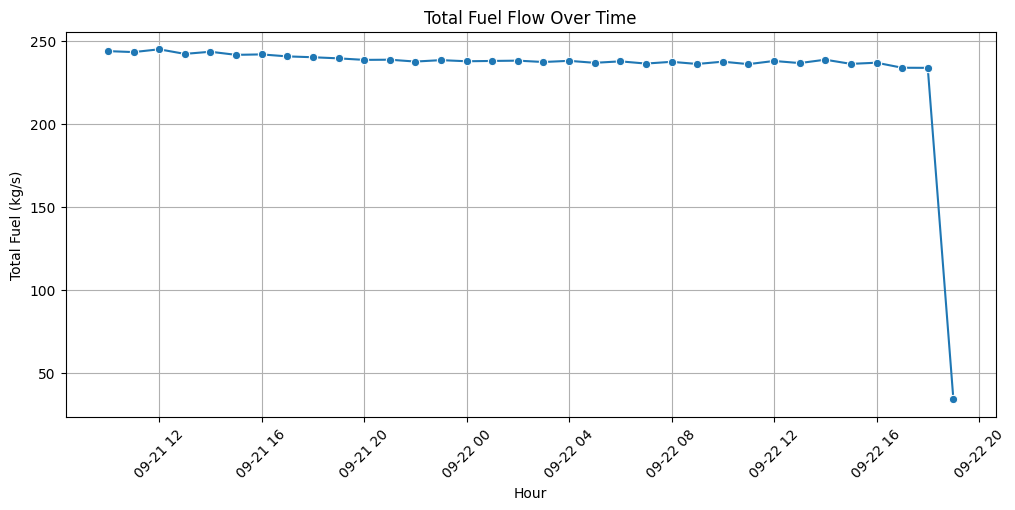

In [72]:
import pandas as pd
import sqlite3

# Connect to database
conn = sqlite3.connect("./data/turbine_data.db")

# Aggregated fuel usage by hour
df1 = pd.read_sql("""
    SELECT 
        strftime('%Y-%m-%d %H', timestamp) AS hour,
        AVG(mf) AS avg_fuel_flow,
        SUM(mf) AS total_fuel
    FROM sensor_readings
    GROUP BY hour
    ORDER BY hour;
""", conn)

# Preview
print(df1.head())

conn.close()


# Convert hour to datetime
df1['hour'] = pd.to_datetime(df1['hour'])

# Plot total fuel over time
plt.figure(figsize=(12,5))
sns.lineplot(data=df1, x='hour', y='total_fuel', marker='o')
plt.title("Total Fuel Flow Over Time")
plt.xlabel("Hour")
plt.ylabel("Total Fuel (kg/s)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


#### Turbine efficiency proxy

             timestamp  efficiency_proxy
0  2025-09-21 10:00:00     255728.355000
1  2025-09-21 10:00:10     265807.360000
2  2025-09-21 10:00:20     326139.210000
3  2025-09-21 10:00:30     473010.245217
4  2025-09-21 10:00:40     708237.620000


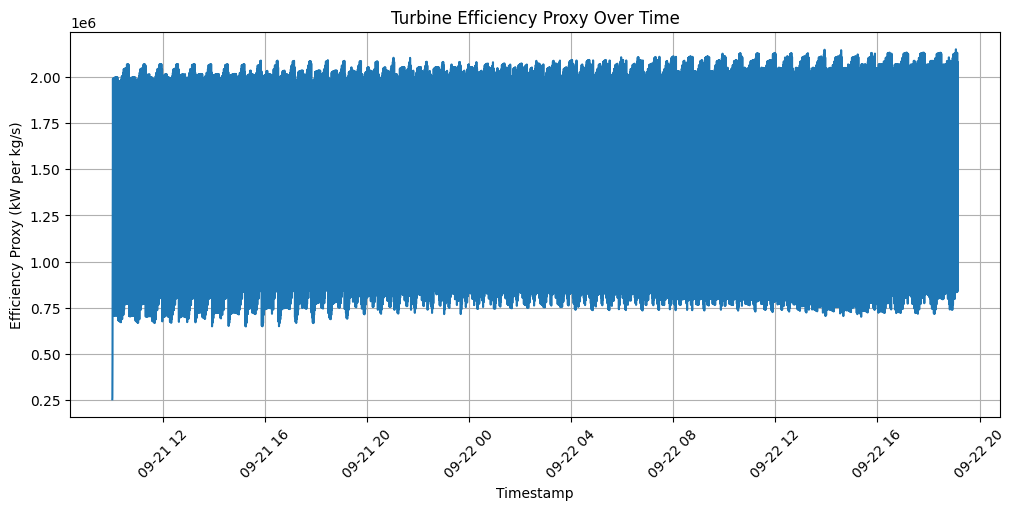

In [73]:
import pandas as pd
import sqlite3

# Connect to database
conn = sqlite3.connect("./data/turbine_data.db")

# Compute turbine efficiency proxy
df_efficiency = pd.read_sql("""
    SELECT 
        timestamp,
        ((ts + tp) * gtn / mf) AS efficiency_proxy
    FROM sensor_readings
    WHERE mf > 0
    ORDER BY timestamp;
""", conn)

# Preview first 5 rows
print(df_efficiency.head())

conn.close()

df_efficiency['timestamp'] = pd.to_datetime(df_efficiency['timestamp'])

# Plot efficiency proxy
plt.figure(figsize=(12,5))
sns.lineplot(data=df_efficiency, x='timestamp', y='efficiency_proxy')
plt.title("Turbine Efficiency Proxy Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Efficiency Proxy (kW per kg/s)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


#### Alerts per turbine

   total_alerts
0         33572


   turbine_id             alert_type  alert_count
0           1         High Fuel Flow        10643
1           1  High Propeller Torque        11930
2           1               High T48        10999


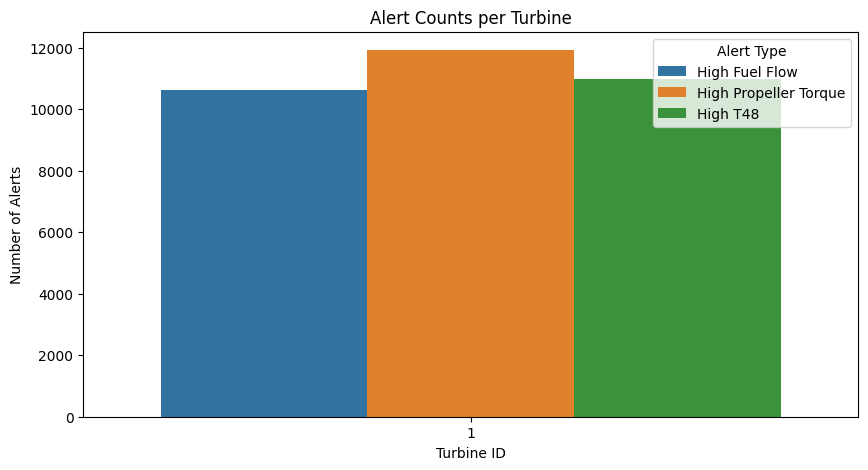

In [74]:
import pandas as pd
import sqlite3

# Connect to database
conn = sqlite3.connect("./data/turbine_data.db")
df_total_alert = pd.read_sql(
    """
    SELECT COUNT(*) AS total_alerts
FROM alerts;

    """
,conn)

# Compute turbine efficiency proxy
df_efficiency = pd.read_sql("""
   SELECT turbine_id, alert_type, COUNT(*) AS alert_count
FROM alerts
GROUP BY turbine_id, alert_type;

""", conn)
print(df_total_alert)
print("\n")
# Preview first 5 rows
print(df_efficiency.head())

conn.close()

plt.figure(figsize=(10,5))
sns.barplot(data=df_efficiency, x='turbine_id', y='alert_count', hue='alert_type')
plt.title("Alert Counts per Turbine")
plt.xlabel("Turbine ID")
plt.ylabel("Number of Alerts")
plt.legend(title="Alert Type")
plt.show()
